# PICC component-chain diagnostics
This clean continuation supersedes the earlier largest-component measurement when a PICC prediction is fragmented. It analyzes all significant components at `imgsz=960` and stops before creating any bridge.

In [1]:
from pathlib import Path
from itertools import combinations

import math
import cv2
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

from scipy.ndimage import distance_transform_edt
from skimage.morphology import skeletonize
from ultralytics import YOLO

MODEL_PATH = Path("best.pt")
IMAGE_PATH = Path("test_images\\L35\\without_dressing\\L35_005.jpg")
DEVICE = "cpu"

assert MODEL_PATH.is_file(), MODEL_PATH.resolve()
assert IMAGE_PATH.is_file(), IMAGE_PATH.resolve()

model = YOLO(str(MODEL_PATH))
model.to(DEVICE)
class_names = {int(k): v for k, v in model.names.items()}
assert model.task == "segment"
assert {"picc", "mark"}.issubset(set(class_names.values()))

original_bgr = cv2.imread(str(IMAGE_PATH))
if original_bgr is None:
    raise RuntimeError(f"Could not read {IMAGE_PATH}")
original_rgb = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB)
image_height, image_width = original_rgb.shape[:2]

print("Image:", IMAGE_PATH)
print("Shape:", original_rgb.shape)
print("Classes:", class_names)


Image: test_images\L35\without_dressing\L35_005.jpg
Shape: (3072, 3072, 3)
Classes: {0: 'mark', 1: 'picc'}


## Stable 960 px inference and PICC extraction

In [2]:
predictions_960 = model.predict(
    source=str(IMAGE_PATH),
    imgsz=960,
    conf=0.50,
    iou=0.70,
    max_det=100,
    device=DEVICE,
    retina_masks=True,
    verbose=False,
)
result_960 = predictions_960[0]

if result_960.boxes is None or result_960.masks is None:
    raise RuntimeError("No segmentation instances returned.")

classes_960 = result_960.boxes.cls.detach().cpu().numpy().astype(int)
confidences_960 = result_960.boxes.conf.detach().cpu().numpy()
masks_960 = result_960.masks.data.detach().cpu().numpy()

picc_candidates_960 = []
mark_candidates_960 = []
for index, class_id in enumerate(classes_960):
    class_name = class_names[int(class_id)]
    print(
        f"Instance {index}: {class_name} | "
        f"confidence={float(confidences_960[index]):.4f}"
    )
    candidate_mask = masks_960[index]
    if candidate_mask.shape != (image_height, image_width):
        candidate_mask = cv2.resize(
            candidate_mask,
            (image_width, image_height),
            interpolation=cv2.INTER_NEAREST,
        )
    candidate_record = {
        "confidence": float(confidences_960[index]),
        "mask": (candidate_mask >= 0.5).astype(np.uint8),
    }
    if class_name == "picc":
        picc_candidates_960.append(candidate_record)
    elif class_name == "mark":
        mark_candidates_960.append(candidate_record)

print("PICC candidates at 960:", len(picc_candidates_960))
if len(picc_candidates_960) != 1:
    raise RuntimeError(
        "Expected exactly one PICC at imgsz=960; "
        "do not select among duplicate PICC predictions automatically."
    )

raw_picc_mask = picc_candidates_960[0]["mask"]
print("Selected PICC confidence:", picc_candidates_960[0]["confidence"])
print("Raw PICC area:", int(raw_picc_mask.sum()))


Instance 0: mark | confidence=0.8902
Instance 1: mark | confidence=0.8617
Instance 2: picc | confidence=0.7119
PICC candidates at 960: 1
Selected PICC confidence: 0.7119185924530029
Raw PICC area: 38845


## Extract and display all significant connected components

All foreground components: 2
Significant threshold: 353
Significant components: 2
Component 0: label=1, area=35322, centroid=(np.float64(1952.0), np.float64(1513.7))
Component 1: label=2, area=3523, centroid=(np.float64(1963.3), np.float64(953.2))


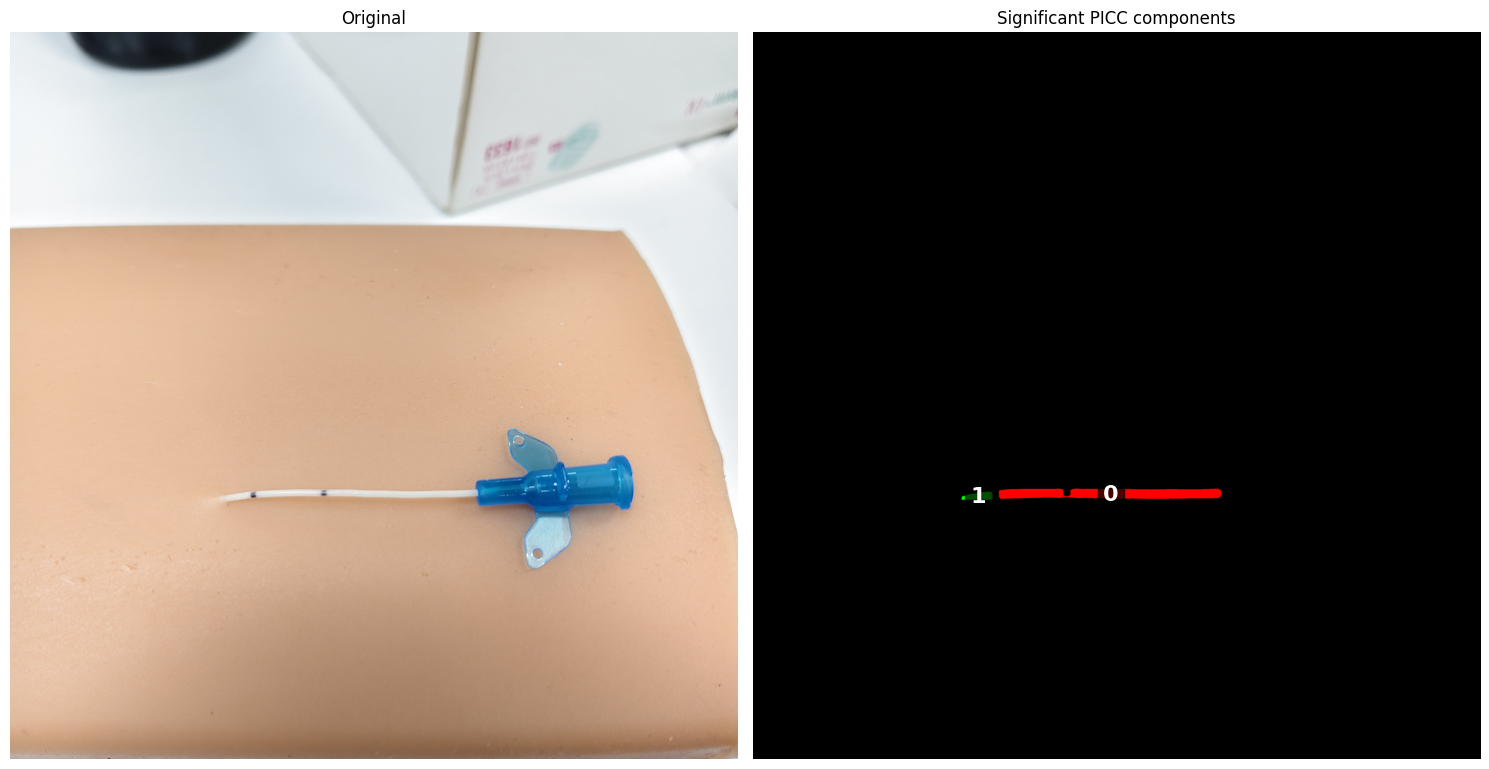

In [3]:
(
    component_count,
    component_labels,
    component_statistics,
    component_centroids,
) = cv2.connectedComponentsWithStats(raw_picc_mask, connectivity=8)

component_areas = component_statistics[1:, cv2.CC_STAT_AREA]
if len(component_areas) == 0:
    raise RuntimeError("PICC mask contains no foreground components.")

largest_area = int(component_areas.max())
significant_threshold = max(50, int(0.01 * largest_area))
significant_labels = [
    label
    for label in range(1, component_count)
    if component_statistics[label, cv2.CC_STAT_AREA]
    >= significant_threshold
]

print("All foreground components:", component_count - 1)
print("Significant threshold:", significant_threshold)
print("Significant components:", len(significant_labels))

for component_id, label in enumerate(significant_labels):
    area = int(component_statistics[label, cv2.CC_STAT_AREA])
    centroid_x, centroid_y = component_centroids[label]
    print(
        f"Component {component_id}: label={label}, area={area}, "
        f"centroid={(round(centroid_y, 1), round(centroid_x, 1))}"
    )

component_colours = [
    (255, 0, 0), (0, 255, 0), (0, 0, 255),
    (255, 255, 0), (255, 0, 255), (0, 255, 255),
]
component_colour_image = np.zeros(
    (image_height, image_width, 3), dtype=np.uint8
)

for component_id, label in enumerate(significant_labels):
    component_colour_image[component_labels == label] = (
        component_colours[component_id % len(component_colours)]
    )

figure, axes = plt.subplots(1, 2, figsize=(15, 9))
axes[0].imshow(original_rgb)
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(component_colour_image)

for component_id, label in enumerate(significant_labels):
    centroid_x, centroid_y = component_centroids[label]
    axes[1].text(
        centroid_x, centroid_y, str(component_id),
        color="white", fontsize=16, fontweight="bold",
        ha="center", va="center",
        bbox={"facecolor": "black", "alpha": 0.7},
    )

axes[1].set_title("Significant PICC components")
axes[1].axis("off")
plt.tight_layout()
plt.show()


## Skeletonize each component independently

In [4]:
def skeleton_to_graph(skeleton):
    graph = nx.Graph()
    coordinates = np.argwhere(skeleton)

    for row, column in coordinates:
        graph.add_node((int(row), int(column)))

    offsets = [(-1, -1), (-1, 0), (-1, 1), (0, 1)]
    for row, column in coordinates:
        current = (int(row), int(column))
        for row_offset, column_offset in offsets:
            neighbour = (
                int(row + row_offset),
                int(column + column_offset),
            )
            if neighbour not in graph:
                continue
            weight = (
                math.sqrt(2)
                if row_offset != 0 and column_offset != 0
                else 1.0
            )
            graph.add_edge(current, neighbour, weight=weight)
    return graph


def longest_component_path(component_mask):
    skeleton = skeletonize(component_mask)
    graph = skeleton_to_graph(skeleton)
    if graph.number_of_nodes() < 2:
        raise RuntimeError("Component skeleton is too short.")

    largest_nodes = max(nx.connected_components(graph), key=len)
    graph = graph.subgraph(largest_nodes).copy()
    endpoints = [
        node for node, degree in graph.degree() if degree == 1
    ]
    if len(endpoints) < 2:
        raise RuntimeError(
            "Component has fewer than two skeleton endpoints."
        )

    longest_length = -1.0
    longest_pair = None
    for first, second in combinations(endpoints, 2):
        length = nx.shortest_path_length(
            graph, first, second, weight="weight"
        )
        if length > longest_length:
            longest_length = float(length)
            longest_pair = (first, second)

    path = nx.shortest_path(
        graph, longest_pair[0], longest_pair[1], weight="weight"
    )
    return {
        "skeleton": skeleton,
        "path": path,
        "path_length": longest_length,
        "endpoints": longest_pair,
    }


component_paths = []
for component_id, label in enumerate(significant_labels):
    component_mask = component_labels == label
    result = longest_component_path(component_mask)
    path_array = np.asarray(result["path"], dtype=np.float64)

    distance_map = distance_transform_edt(component_mask)
    path_widths = 2.0 * distance_map[
        path_array[:, 0].astype(int),
        path_array[:, 1].astype(int),
    ]
    median_width = float(np.median(path_widths))

    component_paths.append({
        "component_id": component_id,
        "label": label,
        "mask": component_mask,
        "path": result["path"],
        "path_array": path_array,
        "path_length": result["path_length"],
        "endpoints": result["endpoints"],
        "median_width": median_width,
        "skeleton": result["skeleton"],
    })

    print(
        f"Component {component_id}: "
        f"path length={result['path_length']:.2f}px, "
        f"median width={median_width:.2f}px, "
        f"endpoints={result['endpoints']}"
    )


Component 0: path length=945.75px, median width=40.00px, endpoints=((1939, 1038), (1950, 1956))
Component 1: path length=119.21px, median width=26.00px, endpoints=((1962, 994), (1975, 881))


## Calculate endpoint directions and score possible component connections

In [5]:
def unit_vector(vector):
    norm = np.linalg.norm(vector)
    return None if norm == 0 else vector / norm


def component_endpoint_records(component, tangent_points=20):
    path = component["path_array"]
    offset = min(tangent_points, len(path) - 1)
    start, start_inside = path[0], path[offset]
    end, end_inside = path[-1], path[-1 - offset]
    return [
        {
            "side": "start",
            "point": start,
            "outward": unit_vector(start - start_inside),
        },
        {
            "side": "end",
            "point": end,
            "outward": unit_vector(end - end_inside),
        },
    ]


def angle_degrees(first_vector, second_vector):
    if first_vector is None or second_vector is None:
        return float("inf")
    cosine = float(
        np.clip(np.dot(first_vector, second_vector), -1.0, 1.0)
    )
    return float(np.degrees(np.arccos(cosine)))


for component in component_paths:
    component["endpoint_records"] = component_endpoint_records(component)

connection_candidates = []
for first_index, second_index in combinations(
    range(len(component_paths)), 2
):
    first_component = component_paths[first_index]
    second_component = component_paths[second_index]

    for first_endpoint in first_component["endpoint_records"]:
        for second_endpoint in second_component["endpoint_records"]:
            bridge_vector = (
                second_endpoint["point"] - first_endpoint["point"]
            )
            gap_distance = float(np.linalg.norm(bridge_vector))
            bridge_direction = unit_vector(bridge_vector)
            first_angle = angle_degrees(
                first_endpoint["outward"], bridge_direction
            )
            second_angle = angle_degrees(
                second_endpoint["outward"], -bridge_direction
            )

            widths = [
                first_component["median_width"],
                second_component["median_width"],
            ]
            average_width = float(np.mean(widths))
            normalized_gap = (
                gap_distance / average_width
                if average_width > 0 else float("inf")
            )
            width_ratio = (
                max(widths) / min(widths)
                if min(widths) > 0 else float("inf")
            )

            connection_candidates.append({
                "component_1": first_index,
                "side_1": first_endpoint["side"],
                "point_1": first_endpoint["point"],
                "component_2": second_index,
                "side_2": second_endpoint["side"],
                "point_2": second_endpoint["point"],
                "gap_px": gap_distance,
                "normalized_gap": normalized_gap,
                "angle_1": first_angle,
                "angle_2": second_angle,
                "width_ratio": width_ratio,
            })

connection_candidates.sort(
    key=lambda item: (
        item["gap_px"], item["angle_1"] + item["angle_2"]
    )
)

print("Closest candidate connections:")
for candidate in connection_candidates[:20]:
    print(
        f"C{candidate['component_1']}-{candidate['side_1']} -> "
        f"C{candidate['component_2']}-{candidate['side_2']} | "
        f"gap={candidate['gap_px']:.2f}px | "
        f"gap/width={candidate['normalized_gap']:.2f} | "
        f"angles={candidate['angle_1']:.1f},"
        f"{candidate['angle_2']:.1f} deg | "
        f"width ratio={candidate['width_ratio']:.2f}"
    )


Closest candidate connections:
C0-start -> C1-start | gap=49.65px | gap/width=1.50 | angles=64.5,27.6 deg | width ratio=1.54
C0-start -> C1-end | gap=161.07px | gap/width=4.88 | angles=49.8,176.2 deg | width ratio=1.54
C0-end -> C1-start | gap=962.07px | gap/width=29.15 | angles=177.9,0.7 deg | width ratio=1.54
C0-end -> C1-end | gap=1075.29px | gap/width=32.58 | angles=178.5,164.6 deg | width ratio=1.54


## Visualize component paths and endpoints
Stop after this cell. It is diagnostic only and does not create virtual bridges.

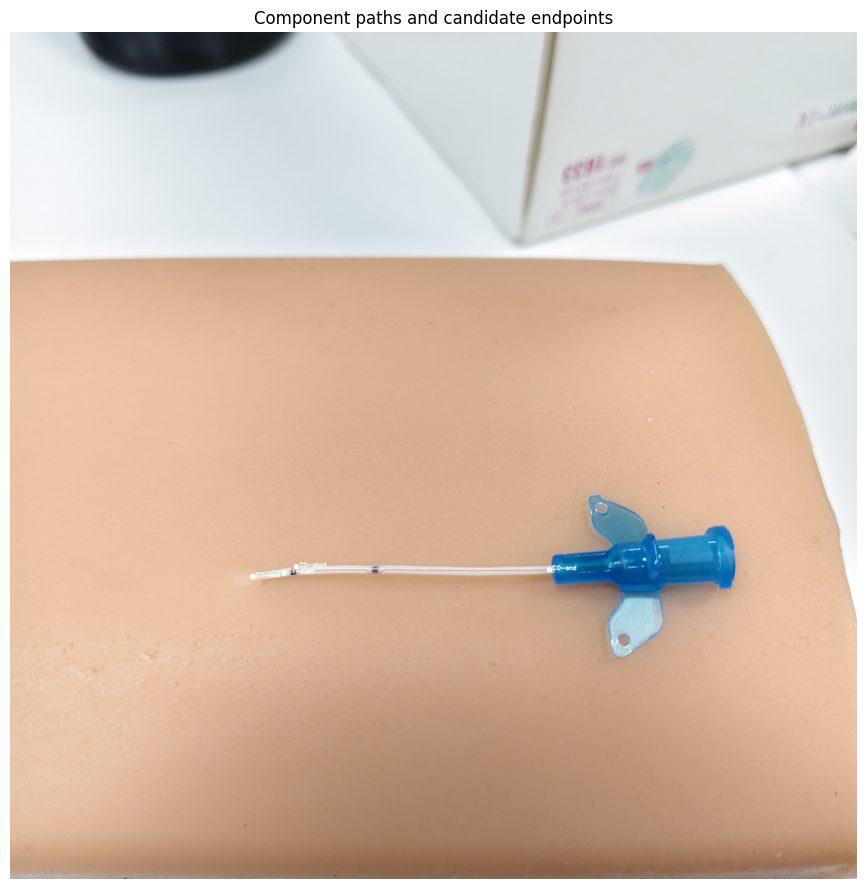

In [6]:
diagnostic_overlay = original_rgb.copy()

for component in component_paths:
    component_id = component["component_id"]
    colour = component_colours[
        component_id % len(component_colours)
    ]
    path_array = component["path_array"].astype(int)
    diagnostic_overlay[
        path_array[:, 0], path_array[:, 1]
    ] = colour

    for endpoint in component["endpoint_records"]:
        row, column = endpoint["point"].astype(int)
        cv2.circle(
            diagnostic_overlay,
            (int(column), int(row)),
            radius=10,
            color=(255, 255, 255),
            thickness=-1,
        )
        cv2.putText(
            diagnostic_overlay,
            f"C{int(component_id)}-{str(endpoint['side'])}",
            (int(column) + 12, int(row)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 255, 255),
            2,
            cv2.LINE_AA,
        )

plt.figure(figsize=(11, 11))
plt.imshow(diagnostic_overlay)
plt.title("Component paths and candidate endpoints")
plt.axis("off")
plt.show()


## Continuous hub-to-insertion PIVC centreline

The next cell excludes abnormally narrow fragments, orders the retained PIVC sections, and joins only geometrically safe gaps with smooth tangent-preserving bridges. A rejected reconstruction must not be used for measurement.

In [7]:
from pivc_centerline import (
    calibrate_length_from_marks,
    reconstruct_continuous_centerline,
    repair_centerline_through_marks,
)

continuous_result = reconstruct_continuous_centerline(component_paths)

print("Retained PIVC components:", continuous_result["component_ids"])
print("Excluded narrow components:", continuous_result["excluded_component_ids"])
for connection in continuous_result["connections"]:
    print(
        f"Accepted bridge: C{connection['from_component']} -> "
        f"C{connection['to_component']} | "
        f"gap={connection['gap_px']:.2f}px | "
        f"gap/width={connection['normalized_gap']:.2f} | "
        f"angles={connection['angle_1']:.1f}/"
        f"{connection['angle_2']:.1f} deg"
    )
print(f"Continuous centreline length: {continuous_result['total_length_px']:.2f} px")
print("Hub-side endpoint (row, column):", continuous_result["hub_endpoint"])
print("Insertion-side endpoint (row, column):", continuous_result["insertion_endpoint"])

mark_centres = []
for mark_candidate in mark_candidates_960:
    mark_pixels = np.argwhere(mark_candidate["mask"] > 0)
    if len(mark_pixels) > 0:
        mark_centres.append(mark_pixels.mean(axis=0))

retained_widths = [
    component["median_width"]
    for component in component_paths
    if component["component_id"] in continuous_result["component_ids"]
]
typical_pivc_width = float(np.median(retained_widths))
mark_repair_result = repair_centerline_through_marks(
    continuous_result["path"],
    mark_centres,
    typical_pivc_width,
)
print("Detected mark centres:", len(mark_centres))
print("Locally repaired marks:", mark_repair_result["repaired_mark_indices"])
for repair in mark_repair_result["repairs"]:
    print(
        f"Mark {repair['mark_index']}: local length "
        f"{repair['original_length_px']:.2f}px -> "
        f"{repair['replacement_length_px']:.2f}px"
    )
print(f"Mark-corrected centreline length: {mark_repair_result['total_length_px']:.2f} px")

calibration_result = calibrate_length_from_marks(
    mark_repair_result["path"],
    mark_centres,
    typical_pivc_width,
    known_spacing_cm=1.0,
)
print(
    "Consecutive 1 cm mark spacings (px):",
    [round(float(value), 2) for value in calibration_result["spacing_pixels"]],
)
print(f"Calibration: {calibration_result['pixels_per_cm']:.2f} px/cm")
print(f"External PIVC length: {calibration_result['length_cm']:.3f} cm")


Retained PIVC components: [0, 1]
Excluded narrow components: []
Accepted bridge: C0 -> C1 | gap=49.65px | gap/width=1.50 | angles=29.2/22.1 deg
Continuous centreline length: 1114.80 px
Hub-side endpoint (row, column): [       1950        1956]
Insertion-side endpoint (row, column): [       1975         881]
Detected mark centres: 2
Locally repaired marks: [0, 1]
Mark 0: local length 116.70px -> 103.38px
Mark 1: local length 117.25px -> 104.03px
Mark-corrected centreline length: 1088.25 px
Consecutive 1 cm mark spacings (px): [298.64]
Calibration: 298.64 px/cm
External PIVC length: 3.644 cm


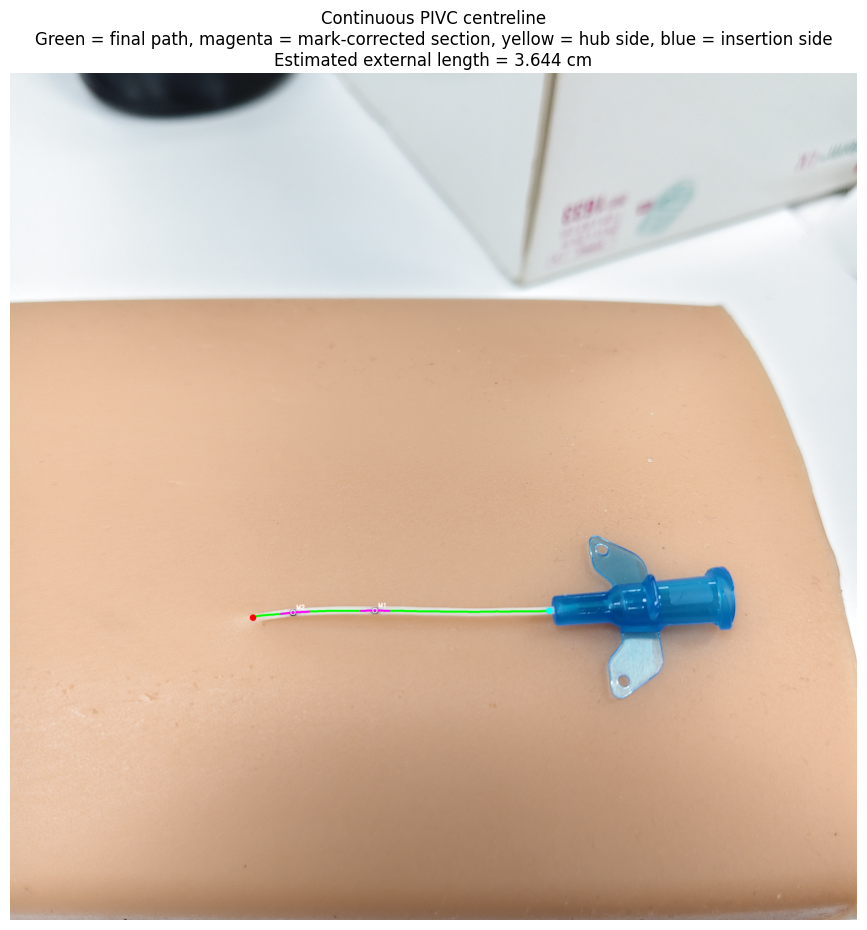

In [8]:
continuous_overlay = original_rgb.copy()

# Green: final continuous, mark-corrected PIVC centreline.
final_points_xy = np.rint(
    mark_repair_result["path"][:, [1, 0]]
).astype(np.int32)
cv2.polylines(
    continuous_overlay, [final_points_xy], False,
    color=(0, 255, 0), thickness=5, lineType=cv2.LINE_AA,
)

# Magenta: local sections reconstructed through detected marks.
for repair in mark_repair_result["repairs"]:
    points_xy = np.rint(
        repair["replacement"][:, [1, 0]]
    ).astype(np.int32)
    cv2.polylines(
        continuous_overlay, [points_xy], False,
        color=(255, 0, 255), thickness=5, lineType=cv2.LINE_AA,
    )
for mark_row, mark_column in mark_centres:
    cv2.circle(
        continuous_overlay,
        (int(round(mark_column)), int(round(mark_row))),
        8, (255, 255, 255), 2,
    )
for mark_number, (mark_row, mark_column) in enumerate(
    calibration_result["projected_mark_points"], start=1
):
    cv2.putText(
        continuous_overlay, f"M{mark_number}",
        (int(round(mark_column)) + 12, int(round(mark_row)) - 12),
        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255),
        2, cv2.LINE_AA,
    )

hub_row, hub_column = np.rint(continuous_result["hub_endpoint"]).astype(int)
tip_row, tip_column = np.rint(continuous_result["insertion_endpoint"]).astype(int)
cv2.circle(continuous_overlay, (hub_column, hub_row), 12, (0, 255, 255), -1)
cv2.circle(continuous_overlay, (tip_column, tip_row), 12, (255, 0, 0), -1)

plt.figure(figsize=(11, 11))
plt.imshow(continuous_overlay)
plt.title(
    "Continuous PIVC centreline\n"
    "Green = final path, magenta = mark-corrected section, "
    "yellow = hub side, blue = insertion side\n"
    f"Estimated external length = {calibration_result['length_cm']:.3f} cm"
)
plt.axis("off")
plt.show()
